# 作业一

（1）随机生成5000条股票价格曲线，画图； μ=6%, σ=13%

股票价格服从几何布朗运动：

$$dS_t = \mu S_t dt + \sigma S_t dW_t$$

离散化形式：

$$S_{t+\Delta t} = S_t \exp\left\{\left(\mu - \frac{1}{2}\sigma^2\right)\Delta t + \sigma \sqrt{\Delta t} Z\right\}$$

其中：
- $\mu = 6\%$ 为漂移率
- $\sigma = 13\%$ 为波动率
- $Z \sim N(0, 1)$ 为标准正态随机变量

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子以保证可重复性
np.random.seed(42)

# 参数设置
mu = 0.06          # 漂移率 (6%)
sigma = 0.13       # 波动率 (13%)
S0 = 100           # 初始股票价格
T = 1.0            # 时间期限 (1年)
n_steps = 242      # 时间步数 (一年242个交易日)
n_paths = 5000     # 模拟路径数
lambda_default = 0.03  # 年违约强度

# 计算时间步长
dt = T / n_steps
p_default = lambda_default * dt

# 生成时间网格
t = np.linspace(0, T, n_steps + 1)

# 生成随机数
Z = np.random.standard_normal((n_paths, n_steps))
U = np.random.random((n_paths, n_steps))

# 初始化价格矩阵
S = np.zeros((n_paths, n_steps + 1))
S[:, 0] = S0

# 初始化违约状态
defaulted = np.zeros(n_paths, dtype=bool)

# 使用几何布朗运动的离散化公式，并加入违约跳到0的判断
for i in range(n_steps):
    alive = ~defaulted
    new_default = alive & (U[:, i] < p_default)
    survive = alive & (~new_default)

    S[new_default, i + 1] = 0
    S[survive, i + 1] = S[survive, i] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[survive, i])

    defaulted |= new_default
    S[defaulted, i + 1] = 0

print(f"参数设置:")
print(f"  漂移率 μ = {mu*100:.1f}%")
print(f"  波动率 σ = {sigma*100:.1f}%")
print(f"  年违约强度 λ = {lambda_default*100:.1f}%")
print(f"  每期违约概率 ≈ {p_default*100:.4f}%")
print(f"  初始价格 S0 = {S0}")
print(f"  模拟路径数 = {n_paths}")
print(f"  时间步数 = {n_steps}")

参数设置:
  漂移率 μ = 6.0%
  波动率 σ = 13.0%
  初始价格 S0 = 100
  模拟路径数 = 5000
  时间步数 = 242


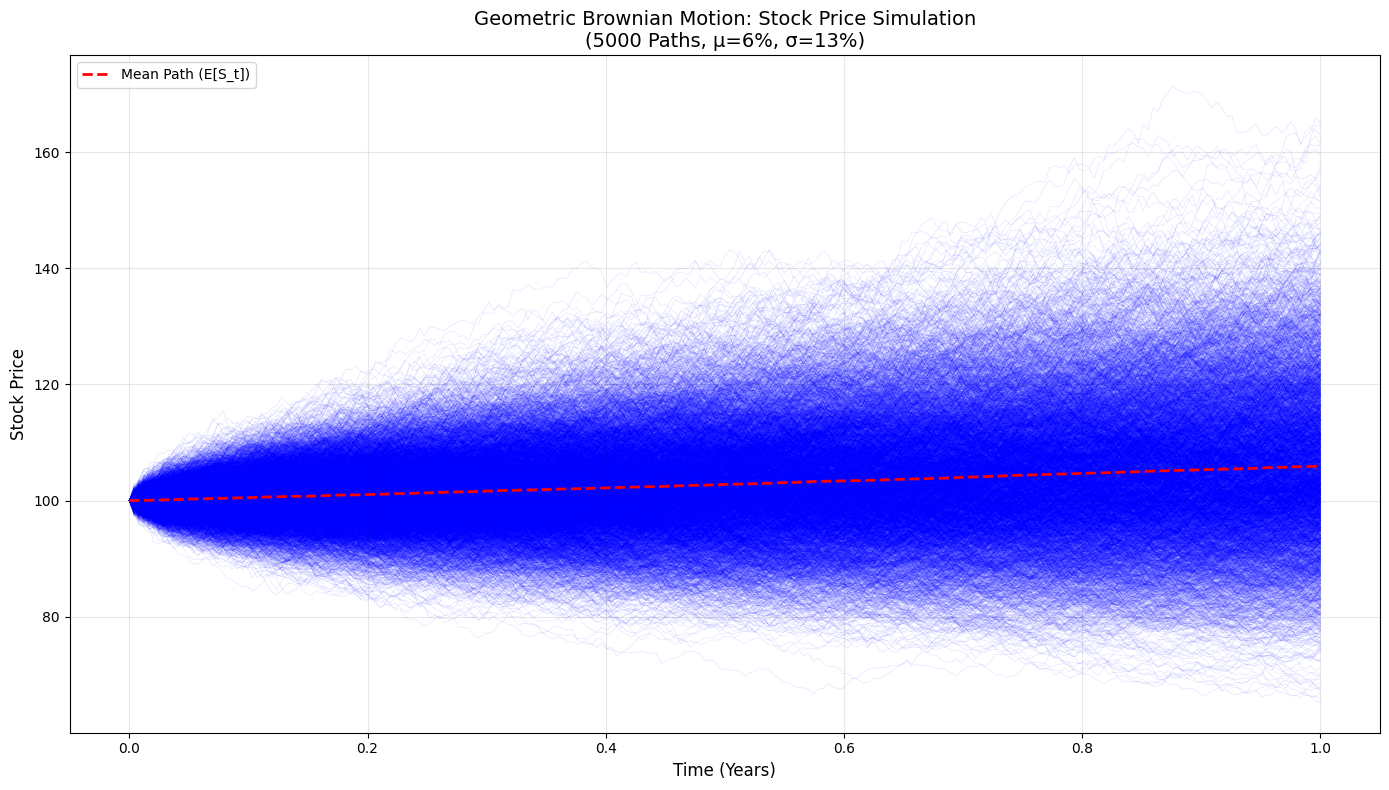

In [3]:
# 创建图形
plt.figure(figsize=(14, 8))

# 绘制所有路径 (使用半透明颜色)
for i in range(n_paths):
    plt.plot(t, S[i, :], alpha=0.1, color='blue', linewidth=0.5)

# 绘制平均路径
mean_path = np.mean(S, axis=0)
plt.plot(t, mean_path, color='red', linewidth=2, label=f'Mean Path (E[S_t])', linestyle='--')

# 设置图形属性
plt.title('Geometric Brownian Motion: Stock Price Simulation\n(5000 Paths, μ=6%, σ=13%)', fontsize=14)
plt.xlabel('Time (Years)', fontsize=12)
plt.ylabel('Stock Price', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

（2）计算每条价格曲线的年化收益率、年化波动率以及最大回撤，画出各统计指标的分布图。

In [ ]:
# 计算每条路径的统计指标

# 1. 年化收益率 (Annualized Return)
annualized_returns = (S[:, -1] / S[:, 0]) ** (1 / T) - 1

# 2. 年化波动率 (Annualized Volatility)
simple_returns = np.zeros((n_paths, n_steps))
previous_prices = S[:, :-1]
current_prices = S[:, 1:]

valid = previous_prices > 0
simple_returns[valid] = current_prices[valid] / previous_prices[valid] - 1
annualized_volatility = np.std(simple_returns, axis=1) * np.sqrt(n_steps)

# 3. 最大回撤 (Maximum Drawdown)
def calculate_max_drawdown(prices):
    cumulative_max = np.maximum.accumulate(prices)
    drawdowns = np.zeros_like(prices)
    positive = cumulative_max > 0
    drawdowns[positive] = (prices[positive] - cumulative_max[positive]) / cumulative_max[positive]
    return np.min(drawdowns)

max_drawdowns = np.array([calculate_max_drawdown(S[i, :]) for i in range(n_paths)])

# 打印统计信息
print("="*60)
print("统计指标汇总")
print("="*60)
print(f"\n年化收益率:")
print(f"  均值: {np.mean(annualized_returns)*100:.4f}%")
print(f"  标准差: {np.std(annualized_returns)*100:.4f}%")
print(f"  最小值: {np.min(annualized_returns)*100:.4f}%")
print(f"  最大值: {np.max(annualized_returns)*100:.4f}%")

print(f"\n年化波动率:")
print(f"  均值: {np.mean(annualized_volatility)*100:.4f}%")
print(f"  标准差: {np.std(annualized_volatility)*100:.4f}%")
print(f"  最小值: {np.min(annualized_volatility)*100:.4f}%")
print(f"  最大值: {np.max(annualized_volatility)*100:.4f}%")
print(f"  参考波动率: {sigma*100:.4f}%")

print(f"\n最大回撤:")
print(f"  均值: {np.mean(max_drawdowns)*100:.4f}%")
print(f"  标准差: {np.std(max_drawdowns)*100:.4f}%")
print(f"  最小值: {np.min(max_drawdowns)*100:.4f}%")
print(f"  最大值: {np.max(max_drawdowns)*100:.4f}%")

统计指标汇总

年化收益率:
  均值: 5.9533%
  标准差: 13.8017%
  最小值: -34.6300%
  最大值: 65.0199%
  理论期望值: 6.0000%

年化波动率:
  均值: 12.9695%
  标准差: 0.5861%
  最小值: 10.8590%
  最大值: 14.9058%
  理论期望值: 13.0000%

最大回撤:
  均值: -12.4497%
  标准差: 4.9377%
  最小值: -37.1876%
  最大值: -3.7415%


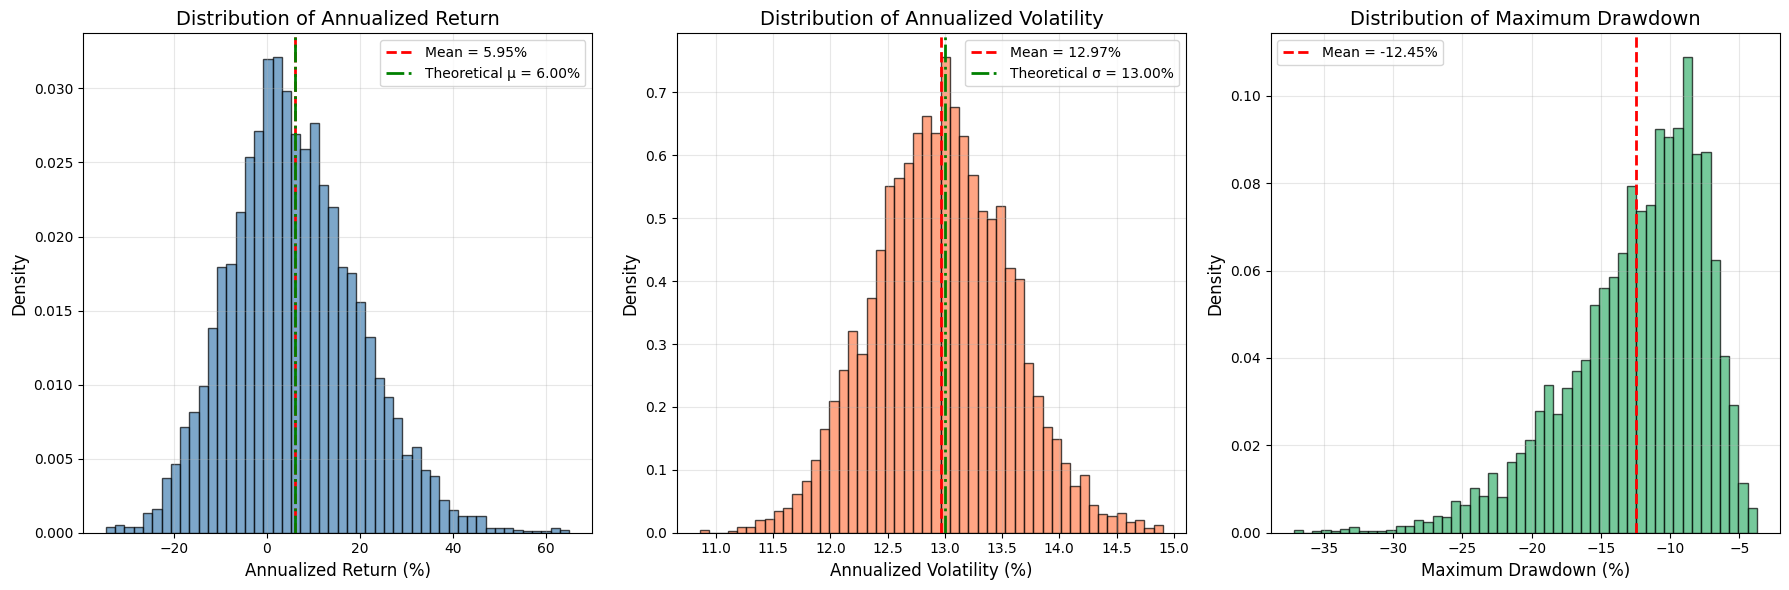

In [ ]:
# 绘制三个统计指标的分布图
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. 年化收益率分布
axes[0].hist(annualized_returns * 100, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(np.mean(annualized_returns) * 100, color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(annualized_returns)*100:.2f}%')
axes[0].set_title('Distribution of Annualized Return', fontsize=14)
axes[0].set_xlabel('Annualized Return (%)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 2. 年化波动率分布
axes[1].hist(annualized_volatility * 100, bins=50, density=True, alpha=0.7, color='coral', edgecolor='black')
axes[1].axvline(np.mean(annualized_volatility) * 100, color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(annualized_volatility)*100:.2f}%')
axes[1].axvline(sigma * 100, color='green', linestyle='-.', linewidth=2, 
                label=f'Reference σ = {sigma*100:.2f}%')
axes[1].set_title('Distribution of Annualized Volatility', fontsize=14)
axes[1].set_xlabel('Annualized Volatility (%)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 3. 最大回撤分布
axes[2].hist(max_drawdowns * 100, bins=50, density=True, alpha=0.7, color='mediumseagreen', edgecolor='black')
axes[2].axvline(np.mean(max_drawdowns) * 100, color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(max_drawdowns)*100:.2f}%')
axes[2].set_title('Distribution of Maximum Drawdown', fontsize=14)
axes[2].set_xlabel('Maximum Drawdown (%)', fontsize=12)
axes[2].set_ylabel('Density', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

可以看到年化收益率分布略微右偏；年化波动率分布较为对称；最大回撤分布明显左偏。

年化收益率分布略微右偏是因为我们使用了简单收益率，从而继承了股票价格的对数正态分布的特征。如果使用的是对数收益率，那么年化收益率分布应该是正态分布。

“波动率对称”是因为抽样统计量触发的中心极限定理。

对于最大回撤的左偏，Gemini给出的解释是：大多数正常的路径，会经历一个处于常规水平的回撤（比如集中在 -10% 到 -15% ），这构成了图上的主体峰值。然而，对于不运气的路径，回撤一旦发生，随着时间推移极易被“放大”（复利下杀），向左侧延伸得非常远。但它又拥有绝对下限（−100%）。常规值拥挤在中右侧，而极端差的值向左侧长长地拖拽，这就形成了左偏。

我有一个不太严谨的想法，我们考虑极端情况：虽然最大回撤分布左右都有边界，但左边界和右边界的概率是不对称的。如果要想达到回撤为0%需要从头到尾一直上涨，但如果要想达到回撤为-100%，其实任何时候都有可能，所以最大回撤分布的左偏是合理的。

（3）假设在每一期dt，公司都有一定的概率破产(jump to bankruptcy), 假设违约破产的概率为3%*dt，且破产后股价为0， 重复（1）和（2）；

- 路径模拟时每期先抽违约事件，违约后股价直接置零并保持不变。
- 曲线会出现“突然跌到 0”的断崖式跳变。
- 收益率分布会左尾加重，破产路径对应 -100%。
- 年化波动率用方法 A：改用简单收益率，再按样本标准差年化。
- 最大回撤会在破产路径上直接变成 -100%。

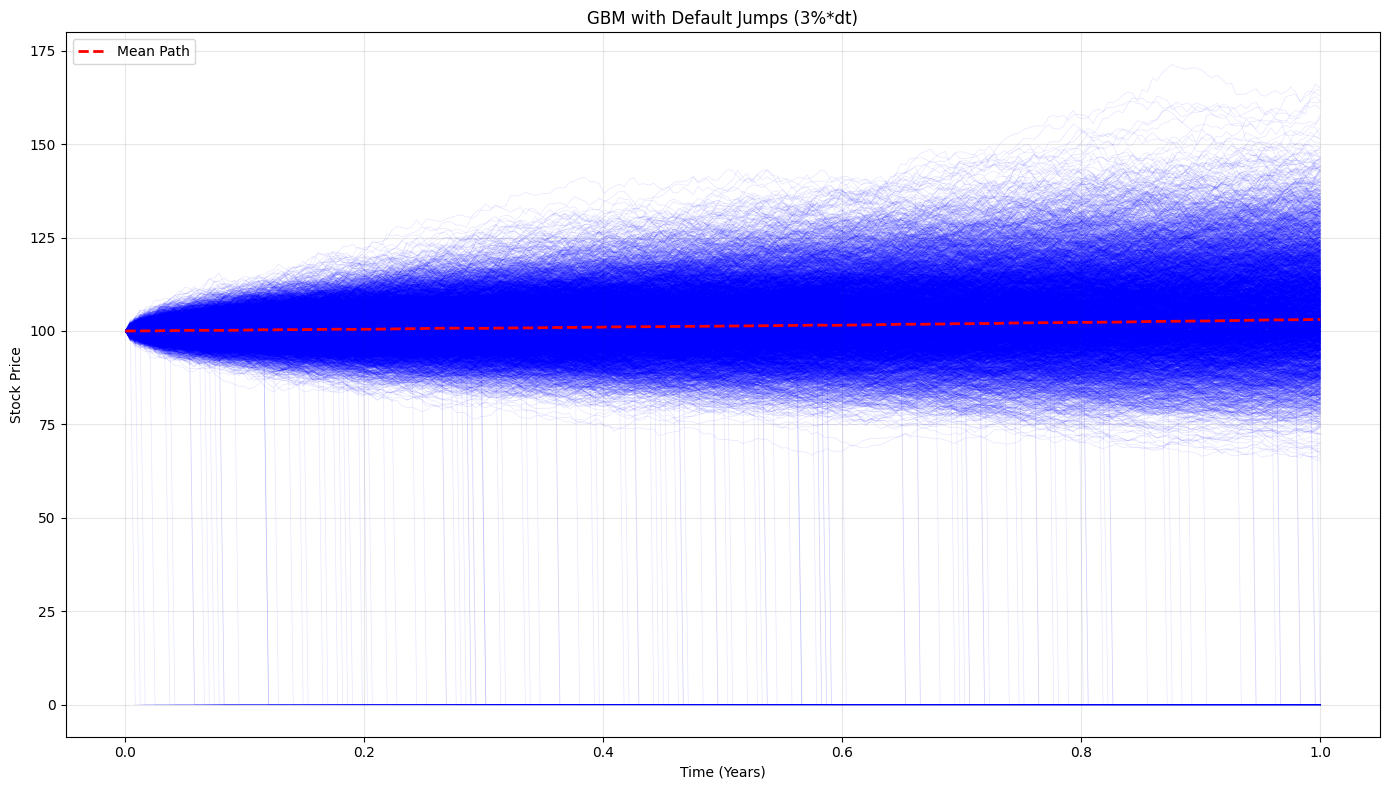

年化收益率: 均值 3.0557%, 标准差 22.0091%, 最小 -100.0000%, 最大 65.0199%
年化波动率: 均值 15.3598%, 标准差 14.2547%, 最小 10.8524%, 最大 100.7977%
最大回撤: 均值 -14.8498%, 标准差 15.0996%, 最小 -100.0000%, 最大 -3.7415%


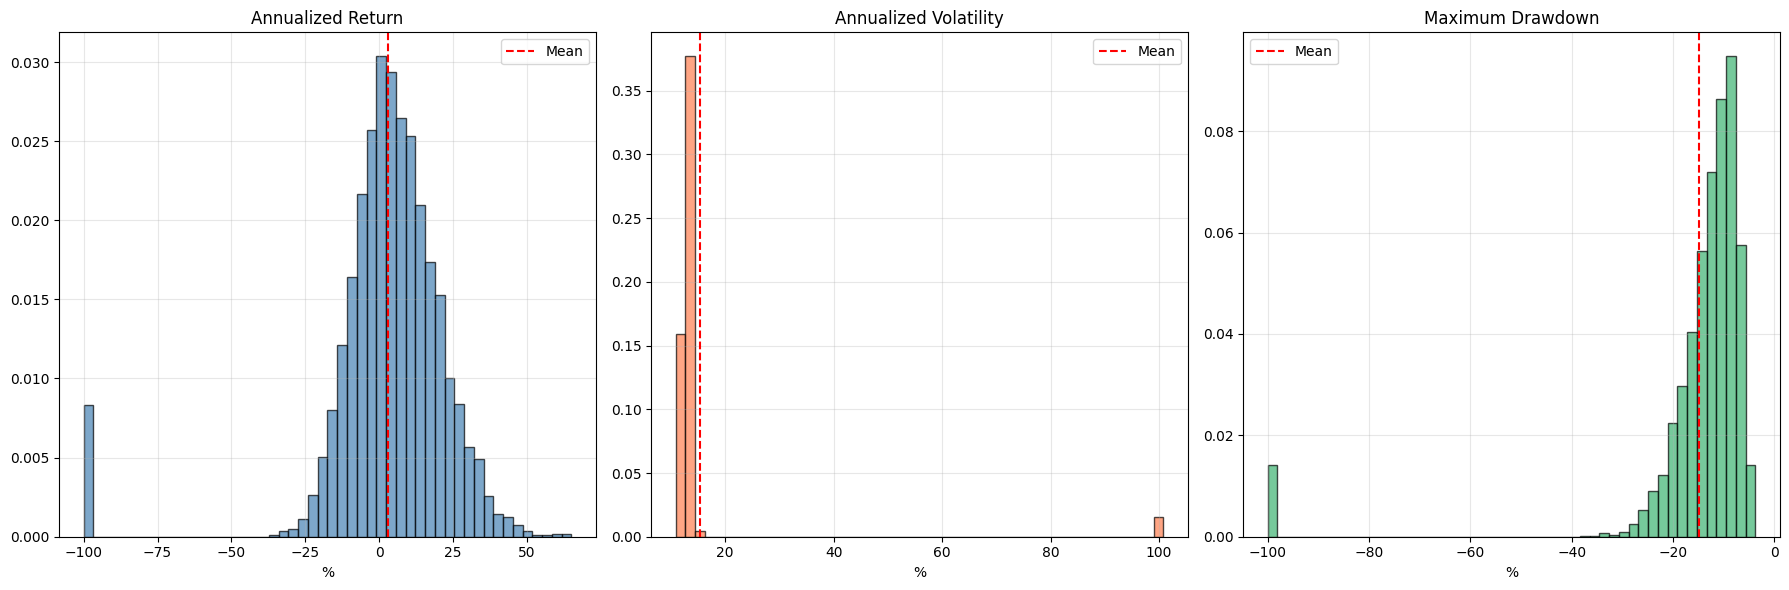

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 参数
mu = 0.06
sigma = 0.13
S0 = 100
T = 1.0
n_steps = 242
n_paths = 5000
lambda_default = 0.03  # 年违约强度
dt = T / n_steps
p_default = lambda_default * dt

np.random.seed(42)
t = np.linspace(0, T, n_steps + 1)
Z = np.random.standard_normal((n_paths, n_steps))
U = np.random.rand(n_paths, n_steps)

S = np.zeros((n_paths, n_steps + 1))
S[:, 0] = S0
defaulted = np.zeros(n_paths, dtype=bool)

# 带违约的路径模拟
for i in range(n_steps):
    alive = ~defaulted
    new_default = alive & (U[:, i] < p_default)
    survive = alive & (~new_default)

    S[new_default, i + 1] = 0
    S[survive, i + 1] = S[survive, i] * np.exp(
        (mu - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z[survive, i]
    )

    defaulted |= new_default
    S[defaulted, i + 1] = 0

# 绘制路径曲线
plt.figure(figsize=(14, 8))
for i in range(n_paths):
    plt.plot(t, S[i, :], alpha=0.1, color='blue', linewidth=0.5)
mean_path = np.mean(S, axis=0)
plt.plot(t, mean_path, color='red', linewidth=2, linestyle='--', label='Mean Path')
plt.title('GBM with Default Jumps (3%*dt)')
plt.xlabel('Time (Years)')
plt.ylabel('Stock Price')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 统计指标
annualized_returns = (S[:, -1] / S[:, 0]) ** (1 / T) - 1

simple_returns = np.zeros((n_paths, n_steps))
prev = S[:, :-1]
curr = S[:, 1:]
valid = prev > 0
simple_returns[valid] = curr[valid] / prev[valid] - 1
annualized_volatility = np.std(simple_returns, axis=1, ddof=0) * np.sqrt(n_steps)

def calculate_max_drawdown(prices):
    cum_max = np.maximum.accumulate(prices)
    dd = np.zeros_like(prices)
    valid = cum_max > 0
    dd[valid] = (prices[valid] - cum_max[valid]) / cum_max[valid]
    return np.min(dd)

max_drawdowns = np.array([calculate_max_drawdown(S[i, :]) for i in range(n_paths)])

# 打印
print("年化收益率: 均值 %.4f%%, 标准差 %.4f%%, 最小 %.4f%%, 最大 %.4f%%" %
      (np.mean(annualized_returns) * 100, np.std(annualized_returns) * 100,
       np.min(annualized_returns) * 100, np.max(annualized_returns) * 100))
print("年化波动率: 均值 %.4f%%, 标准差 %.4f%%, 最小 %.4f%%, 最大 %.4f%%" %
      (np.mean(annualized_volatility) * 100, np.std(annualized_volatility) * 100,
       np.min(annualized_volatility) * 100, np.max(annualized_volatility) * 100))
print("最大回撤: 均值 %.4f%%, 标准差 %.4f%%, 最小 %.4f%%, 最大 %.4f%%" %
      (np.mean(max_drawdowns) * 100, np.std(max_drawdowns) * 100,
       np.min(max_drawdowns) * 100, np.max(max_drawdowns) * 100))

# 分布图
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].hist(annualized_returns * 100, bins=50, density=True, alpha=0.7,
             color='steelblue', edgecolor='black')
axes[0].axvline(np.mean(annualized_returns) * 100, color='red', linestyle='--', label='Mean')
axes[0].set_title('Annualized Return')
axes[0].set_xlabel('%')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(annualized_volatility * 100, bins=50, density=True, alpha=0.7,
             color='coral', edgecolor='black')
axes[1].axvline(np.mean(annualized_volatility) * 100, color='red', linestyle='--', label='Mean')
axes[1].set_title('Annualized Volatility')
axes[1].set_xlabel('%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(max_drawdowns * 100, bins=50, density=True, alpha=0.7,
             color='mediumseagreen', edgecolor='black')
axes[2].axvline(np.mean(max_drawdowns) * 100, color='red', linestyle='--', label='Mean')
axes[2].set_title('Maximum Drawdown')
axes[2].set_xlabel('%')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

很明显，加入破产事件后，分布会向相应方向偏移。年化收益率的右偏被拉回一些；年化波动率分布转向右偏；最大回撤分布的左偏加剧。

我想到的问题是，如果我们单纯假设股票价格为GBM，而忽略了破产事件，我们很容易低估极端情况。此外，由于破产事件在很远的点上形成尖峰，VaR这样的风险指标可能也会失效，ES才能检测出来。